# INFOMTALC 2026: Midterm assignment 1
## Transformer-based chess player
# Training

In [ ]:
#!pip install chess trl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 78.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 34.2 MB/s eta 0:00:00
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=d1614e2fe45ca2153a615626b5b8a31dcd2d53a8344724db2172a81258110211
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [ ]:
import pandas as pd
import chess
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
from transformers import EarlyStoppingCallback
from transformers import AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
from transformers import EarlyStoppingCallback
import numpy as np
import chess.pgn
import random
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from datasets import Dataset
import matplotlib.pyplot as plt

In [ ]:
import random
import numpy as np
import torch

# set seed value
SEED = 42

# python random
random.seed(SEED)

# numpy
np.random.seed(SEED)

# pytorch
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# Load openings train
openings = pd.read_csv("openings.csv")
openings.head()

,eco-volume,eco,name,pgn,uci,epd
0,A,A00,Amar Opening,1. Nh3,g1h3,rnbqkbnr/pppppppp/8/8/8/7N/PPPPPPPP/RNBQKB1R b...
1,A,A00,Amar Opening: Paris Gambit,1. Nh3 d5 2. g3 e5 3. f4,g1h3 d7d5 g2g3 e7e5 f2f4,rnbqkbnr/ppp2ppp/8/3pp3/5P2/6PN/PPPPP2P/RNBQKB...
2,A,A00,"Amar Opening: Paris Gambit, Gent Gambit",1. Nh3 d5 2. g3 e5 3. f4 Bxh3 4. Bxh3 exf4 5. ...,g1h3 d7d5 g2g3 e7e5 f2f4 c8h3 f1h3 e5f4 e1g1 f...,rn1qkbnr/ppp2ppp/8/3p4/8/6PB/PPPPP3/RNBQ1RK1 b...
3,A,A00,Amsterdam Attack,1. e3 e5 2. c4 d6 3. Nc3 Nc6 4. b3 Nf6,e2e3 e7e5 c2c4 d7d6 b1c3 b8c6 b2b3 g8f6,r1bqkb1r/ppp2ppp/2np1n2/4p3/2P5/1PN1P3/P2P1PPP...
4,A,A00,Anderssen's Opening,1. a3,a2a3,rnbqkbnr/pppppppp/8/8/8/P7/1PPPPPPP/RNBQKBNR b...


In [ ]:
opening_moves = []

for _, row in openings.iterrows():
    # uci move sequence
    uci_line = str(row["uci"]).strip()

    if not uci_line or uci_line == "nan":
        continue

    board = chess.Board()
    # split into individual moves
    moves = uci_line.split()

    valid_line = True

    # iterate through the individual moves
    for uci in moves:
        # current board position as fen
        fen = board.fen()

        # save current position to next move
        opening_moves.append({
            "fen": fen,
            "move": uci
        })

        # apply move
        try:
            # cnvert uci into a chess move object
            move = chess.Move.from_uci(uci)
            # check if move is legal
            if move not in board.legal_moves:
                # stop processing opening line
                valid_line = False
                break
            # apply legal move to board
            board.push(move)
        except Exception:
            valid_line = False
            break

max_games = 2000
min_plies = 15
games = 0
lichess_moves = []

with open("lichess_elite_2021-12.pgn", "r", encoding="utf-8", errors="ignore") as f:
    # keep reading games until max
    while games < max_games:
        # read one game
        game = chess.pgn.read_game(f)
        # stop when there are no more games
        if game is None:
            break

        if random.random() > 0.05:
            continue

        moves = list(game.mainline_moves())
        # keep games longer than 20 plies, if fewer then keep with smaller prob
        if len(moves) < min_plies and random.random() > 0.2:
            continue

        games += 1

        # start from the initial board for this game
        board = game.board()

        # go through moves in order
        for move in moves:
            # save one training example
            lichess_moves.append({
                "fen": board.fen(),
                "move": move.uci()
            })
            # apply the move to get next position
            board.push(move)

train_df = pd.DataFrame(lichess_moves)
train_df.to_csv("lichess_train_2000.csv", index=False)

print(train_df.head())
print("rows:", len(train_df))

# Convert to dataframe
openings_df = pd.DataFrame(opening_moves)

print(openings_df.head())
print("Opening lines:", len(openings_df))

# Remove duplicate moves of openings
openings_df = openings_df.drop_duplicates(subset=["fen", "move"])

                                                 fen  move
0  rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...  d2d4
1  rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...  d7d5
2  rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...  c1f4
3  rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...  g8f6
4  rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/8/PPP1PPPP/RN1...  e2e3
rows: 167285
                                                 fen  move
0  rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...  g1h3
1  rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...  g1h3
2  rnbqkbnr/pppppppp/8/8/8/7N/PPPPPPPP/RNBQKB1R b...  d7d5
3  rnbqkbnr/ppp1pppp/8/3p4/8/7N/PPPPPPPP/RNBQKB1R...  g2g3
4  rnbqkbnr/ppp1pppp/8/3p4/8/6PN/PPPPPP1P/RNBQKB1...  e7e5
Opening lines: 34759


In [ ]:
openings_df = openings_df.drop_duplicates(subset=["fen", "move"])

In [ ]:
len(openings_df)

7810

In [ ]:
# merge openings + lichess
full_df = pd.concat([openings_df, train_df], ignore_index=True)

model_name = "Qwen/Qwen2.5-0.5B"

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

if tokenizer.pad_token is None:
   tokenizer.pad_token = tokenizer.eos_token

# make  training format in text
full_df["text"] = full_df.apply(lambda x: f"FEN: {x['fen']}\nMOVE: {x['move']}{tokenizer.eos_token}", axis=1)

print(full_df[["fen", "move", "text"]].head())

# split data into train + val
train_split, val_split = train_test_split(full_df, test_size=0.1, random_state=42)

train_split[["text"]].to_json("train.jsonl", orient="records", lines=True)
val_split[["text"]].to_json("val.jsonl", orient="records", lines=True)

print("train rows:", len(train_split))
print("val rows:", len(val_split))

# save merged dataset
full_df.to_csv("train_full.csv", index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

                                                 fen  move  \
0  rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...  g1h3   
1  rnbqkbnr/pppppppp/8/8/8/7N/PPPPPPPP/RNBQKB1R b...  d7d5   
2  rnbqkbnr/ppp1pppp/8/3p4/8/7N/PPPPPPPP/RNBQKB1R...  g2g3   
3  rnbqkbnr/ppp1pppp/8/3p4/8/6PN/PPPPPP1P/RNBQKB1...  e7e5   
4  rnbqkbnr/ppp2ppp/8/3pp3/8/6PN/PPPPPP1P/RNBQKB1...  f2f4   

                                                text  
0  FEN: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKB...  
1  FEN: rnbqkbnr/pppppppp/8/8/8/7N/PPPPPPPP/RNBQK...  
2  FEN: rnbqkbnr/ppp1pppp/8/3p4/8/7N/PPPPPPPP/RNB...  
3  FEN: rnbqkbnr/ppp1pppp/8/3p4/8/6PN/PPPPPP1P/RN...  
4  FEN: rnbqkbnr/ppp2ppp/8/3pp3/8/6PN/PPPPPP1P/RN...  
train rows: 157585
val rows: 17510


In [ ]:
# keep only text column
train_text_df = train_split[["text"]].reset_index(drop=True)
val_text_df = val_split[["text"]].reset_index(drop=True)

# convert pandas to HF df
train_set = Dataset.from_pandas(train_text_df, preserve_index=False)
val_set = Dataset.from_pandas(val_text_df, preserve_index=False)

print(train_set[0]["text"])
print(val_set[0]["text"])

# Source: https://huggingface.co/docs/datasets/v1.4.0/processing.html

FEN: r2qkbnr/ppp1pppp/2n5/3p1b2/3P1B2/4P3/PPP2PPP/RN1QKBNR w KQkq - 1 4
MOVE: g1f3<|endoftext|>
FEN: rn1qk2r/1b5p/p3pp2/1pp5/5P2/3P1NP1/P1PB2BP/Q4RK1 b kq - 1 14
MOVE: b8c6<|endoftext|>


In [ ]:

out_dir = "new_trained_model2"

BATCH_SIZE = 4
GRAD_ACCUM = 4
MAX_STEPS = 10000
LR = 2e-4

# detect training device
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

# base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

model.to(device)

# LoRA configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# training arguments
training_args = TrainingArguments(
    output_dir=out_dir,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    eval_strategy="steps",
    eval_steps=500,
    load_best_model_at_end=True,
    max_steps=MAX_STEPS,
    learning_rate=LR,
    fp16=torch.cuda.is_available(),
    logging_steps=25,
    save_steps=500,
    save_total_limit=2,
    report_to="none",
    optim="adamw_torch",
)

# trainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_set,
    eval_dataset=val_set,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# train
trainer.train()


# source: https://medium.com/@balci.pelin/slm-finetuning-part-1-1f0087e91d58
#         https://giacomopedemonte.medium.com/running-transformer-models-without-a-gpu-overcoming-the-flash-attn-dependency-08f785675641
#         https://teodoracoach.substack.com/p/day-5-the-main-event-fine-tuning
#         https://www.kaggle.com/discussions/general/514324

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


Adding EOS to train dataset:   0%|          | 0/157585 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/157585 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/157585 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/17510 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/17510 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
500,1.055681,1.052629
1000,0.984417,0.987809
1500,0.976620,0.954839
2000,0.940522,0.930968
2500,0.938375,0.918491
3000,0.932333,0.905578
3500,0.904946,0.894422
4000,0.880244,0.885729
4500,0.877689,0.877914
5000,0.882024,0.872607


TrainOutput(global_step=10000, training_loss=0.9019729944229126, metrics={'train_runtime': 14590.8141, 'train_samples_per_second': 10.966, 'train_steps_per_second': 0.685, 'total_flos': 2.22206028192192e+16, 'train_loss': 0.9019729944229126})

In [ ]:
# save LoRA adapter
trainer.model.save_pretrained(out_dir)
tokenizer.save_pretrained(out_dir)

print("Training finished. Adapter saved to:", out_dir)

Training finished. Adapter saved to: new_trained_model2


In [ ]:
from huggingface_hub import HfApi
from transformers import AutoTokenizer

model_dir = "new_trained_model2"
repo_id = "grapju/trained_model_chess"

# create repo if it does not exist
api = HfApi()
api.create_repo(repo_id=repo_id, exist_ok=True)

# load tokenizer used during training
tokenizer = AutoTokenizer.from_pretrained(model_dir)

# push tokenizer
tokenizer.push_to_hub(repo_id)

# upload adapter files
api.upload_folder(
    folder_path=model_dir,
    repo_id=repo_id,
    repo_type="model",
)

print("Model pushed to:", f"https://huggingface.co/{repo_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpk6o4b0df/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

  ...oint-10000/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

  ...heckpoint-10000/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...point-10000/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...ckpoint-9500/optimizer.pt:   0%|          | 37.9kB / 17.5MB            

Model pushed to: https://huggingface.co/grapju/trained_model_chess


               plies
count  490422.000000
mean       82.707018
std        35.453296
min         0.000000
25%        57.000000
50%        78.000000
75%       105.000000
max       601.000000


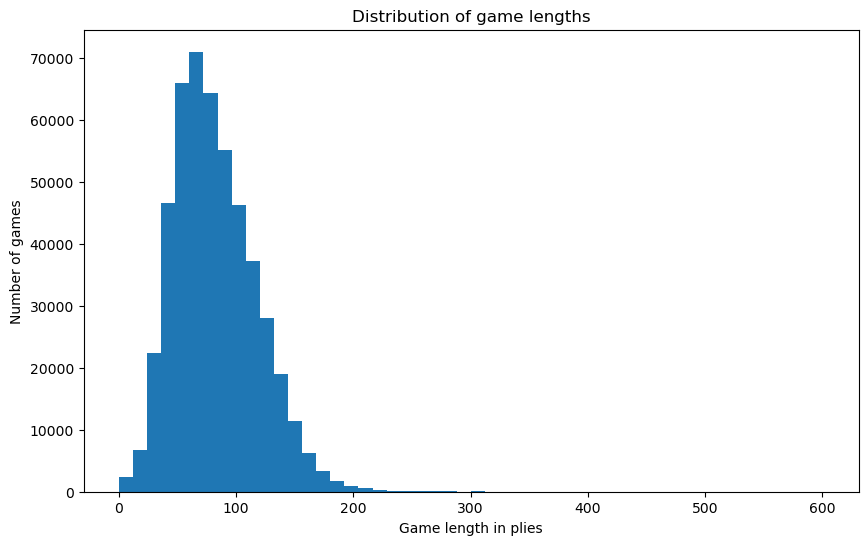

In [ ]:
game_lengths = []

with open("lichess_elite_2021-12.pgn", "r", encoding="utf-8", errors="ignore") as f:
    while True:
        game = chess.pgn.read_game(f)
        if game is None:
            break

        moves = list(game.mainline_moves())
        # number of plies per game
        game_lengths.append(len(moves))

lengths_df = pd.DataFrame({"plies": game_lengths})

print(lengths_df.describe())

plt.figure(figsize=(10, 6))
plt.hist(lengths_df["plies"], bins=50)
plt.xlabel("Game length in plies")
plt.ylabel("Number of games")
plt.title("Distribution of game lengths")
plt.show()